
# Crop Recommendation AI
## Final EDA, Model Selection, Training and Evaluation

### Objective
This notebook develops an AI-powered crop recommendation system for agricultural extension agents.

The model uses:
- Soil nutrients (Nitrogen, Phosphorus, Potassium)
- Environmental conditions (Temperature, Humidity, Rainfall)
- Soil texture

The goal is to recommend suitable crops and provide evidence-based explanations.

Models evaluated:
1. Random Forest
2. XGBoost
3. Gradient Boosting

Evaluation metrics:
- Accuracy
- Macro F1 Score
- Weighted F1 Score
- Confusion Matrix

### Why these models?

Tree-based ensemble models are suitable for agricultural prediction because crop suitability depends on complex relationships between multiple factors.

For example:
- High rainfall alone does not determine rice suitability.
- Rainfall combined with humidity, soil texture and nutrient levels provides stronger prediction signals.



In [3]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [4]:

# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib



## 1. Load Dataset

The dataset contains soil and environmental conditions linked to recommended crop classes.


In [5]:

df = pd.read_csv("original_dataset.csv")

df.head()


,N,P,K,temperature,humidity,ph,rainfall,soil,crop_label
0,40,27,45,21.66,94.79,5.89,112.43,sandy loam,guinea_corn
1,120,7,47,24.25,83.04,6.65,54.77,loamy clay,pepper
2,102,11,47,27.99,92.78,6.50,27.15,sandy loam,tomatoes
3,5,25,6,30.72,94.01,6.01,106.81,loamy,orange
4,36,43,21,28.36,84.86,7.14,52.93,loamy,yam


In [6]:

# Check dataset structure

print("Dataset shape:", df.shape)

df.info()


Dataset shape: (5000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            5000 non-null   int64  
 1   P            5000 non-null   int64  
 2   K            5000 non-null   int64  
 3   temperature  5000 non-null   float64
 4   humidity     5000 non-null   float64
 5   ph           5000 non-null   float64
 6   rainfall     5000 non-null   float64
 7   soil         5000 non-null   object 
 8   crop_label   5000 non-null   object 
dtypes: float64(4), int64(3), object(2)
memory usage: 351.7+ KB



## 2. Data Cleaning

The dataset contained exact duplicate observations.

Removing duplicates is important because:
- duplicated records can cause data leakage;
- the model may appear more accurate than it actually is;
- validation results become unrealistic.

Therefore, duplicates are removed before training.


In [7]:

print("Duplicate rows:", df.duplicated().sum())

df_clean = df.drop_duplicates().reset_index(drop=True)

# Rename column to make it descriptive
df_clean = df_clean.rename(
    columns={"soil":"soil_texture"}
)

print("Clean dataset shape:", df_clean.shape)


Duplicate rows: 4000
Clean dataset shape: (1000, 9)



## 3. Exploratory Data Analysis

Understanding the dataset helps identify:
- class balance;
- feature behaviour;
- possible relationships between soil/environment factors and crops.


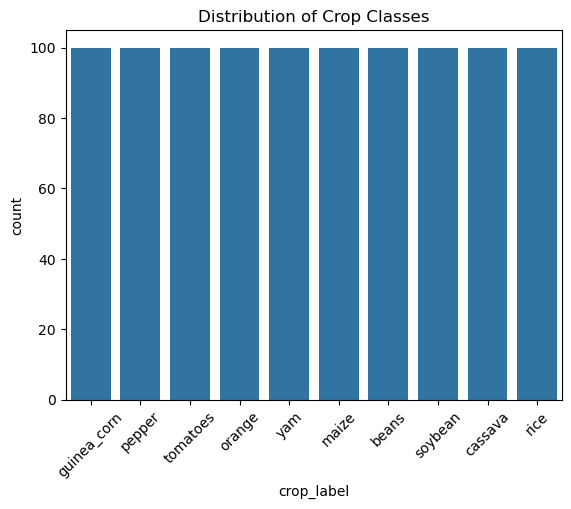

In [8]:

sns.countplot(
    data=df_clean,
    x="crop_label"
)

plt.xticks(rotation=45)
plt.title("Distribution of Crop Classes")
plt.show()


In [11]:
df_clean.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,51.769000,41.612000,34.926000,24.242380,69.624920,6.576580,91.669540
std,34.415986,22.455862,20.456661,4.659018,27.040132,0.642984,57.265234
min,0.000000,5.000000,5.000000,10.010000,14.260000,5.010000,20.210000
25%,23.000000,21.000000,18.000000,20.325000,61.890000,6.120000,55.950000
50%,40.000000,44.000000,30.000000,24.690000,82.710000,6.535000,78.115000
75%,83.000000,60.000000,47.000000,27.937500,89.950000,6.970000,108.572500
max,120.000000,80.000000,85.000000,34.950000,95.000000,8.870000,298.560000


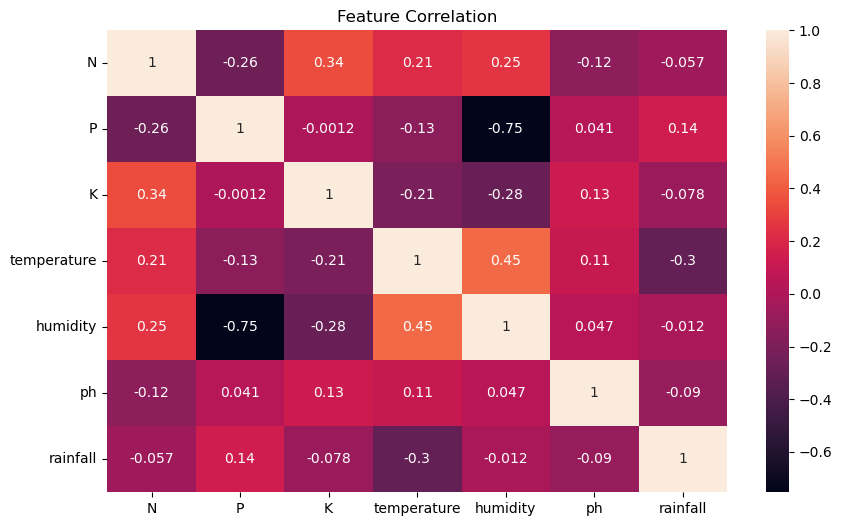

In [12]:

numeric_features = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

plt.figure(figsize=(10,6))

sns.heatmap(
    df_clean[numeric_features].corr(),
    annot=True
)

plt.title("Feature Correlation")
plt.show()



## 4. Prepare Data For Modelling

The soil texture variable is categorical.

One-hot encoding converts soil categories into numerical values that machine learning models can understand.

Example:

loamy soil → [1,0,0,0]

sandy soil → [0,1,0,0]


In [13]:
# Separate features and target
X = df_clean.drop("crop_label", axis=1)

y = df_clean["crop_label"]

# Encode target labels for XGBoost
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "soil_encoder",
            OneHotEncoder(handle_unknown="ignore"),
            ["soil_texture"]
        )
    ],
    remainder="passthrough"
)


# 5. Model Selection

Three ensemble models are compared.

## Random Forest
Uses multiple independent decision trees.

Advantages:
- robust;
- easy interpretation;
- good performance on small datasets.

## XGBoost
Builds trees sequentially and learns from previous errors.

Advantages:
- captures complex relationships;
- often performs strongly on structured/tabular data.

## Gradient Boosting
Another boosting approach that improves predictions sequentially.


In [14]:

models = {

"Random Forest":
RandomForestClassifier(
    n_estimators=300,
    random_state=42
),

"XGBoost":
XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="mlogloss"
),

"Gradient Boosting":
GradientBoostingClassifier(
    random_state=42
)

}


results = {}


for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    pipeline.fit(
        X_train,
        y_train
    )


    predictions = pipeline.predict(
        X_test
    )


    results[name] = {

        "Accuracy":
        accuracy_score(
            y_test,
            predictions
        ),

        "Macro F1":
        f1_score(
            y_test,
            predictions,
            average="macro"
        ),

        "Weighted F1":
        f1_score(
            y_test,
            predictions,
            average="weighted"
        )

    }


pd.DataFrame(results).T


,Accuracy,Macro F1,Weighted F1
Random Forest,1.0,1.0,1.0
XGBoost,1.0,1.0,1.0
Gradient Boosting,1.0,1.0,1.0



## Interpretation of Results

Accuracy alone is not enough.

Macro F1:
- treats every crop equally;
- important because every crop class should be predicted fairly.

Weighted F1:
- considers the number of samples in each crop class;
- useful when class sizes differ.

Because the dataset is balanced, Macro and Weighted F1 should be similar.

If all models achieve similar scores, model choice should consider:
- explainability;
- deployment;
- ability to justify recommendations.



In [15]:

# Train final XGBoost model

final_model = Pipeline([
    ("preprocessing", preprocessor),
    (
        "model",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            random_state=42,
            eval_metric="mlogloss"
        )
    )
])


final_model.fit(
    X_train,
    y_train
)


y_pred = final_model.predict(
    X_test
)


print(classification_report(
    y_test,
    y_pred
))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00        20

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200




# 6. Confusion Matrix

The confusion matrix shows where the model correctly predicts crops and where errors occur.

A strong model should have:
- high values on the diagonal;
- few incorrect classifications outside the diagonal.


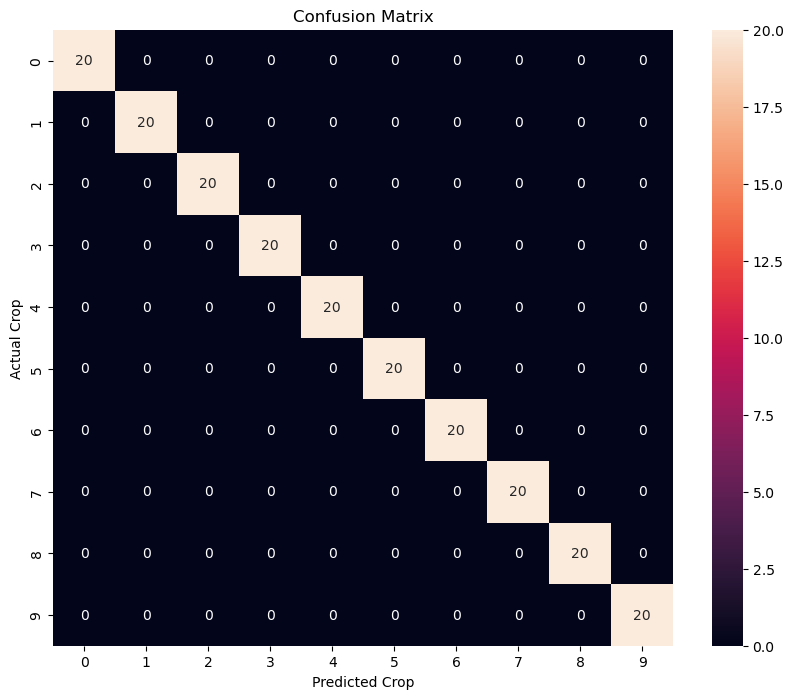

In [16]:

cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=final_model.classes_,
    yticklabels=final_model.classes_
)

plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")

plt.title("Confusion Matrix")

plt.show()



# 7. Save Model

The saved model will be used by Streamlit.

The application will:
- collect farm measurements from an agricultural agent;
- predict suitable crops;
- display the top recommendations.


In [17]:

joblib.dump(
    final_model,
    "crop_prediction_model2.pkl"
)


['crop_prediction_model2.pkl']

In [18]:
# Save label encoder
joblib.dump(
    label_encoder,
    "crop_label_encoder.pkl"
)

['crop_label_encoder.pkl']